# Practical Exercises

 - The aim of this notebook is to guide you through a few exercises in machine-learning for image processing.
 - We will work through some simple examples of discriminative and generative AI concepts, using the following core packages:
     - [`PyTorch`](https://docs.pytorch.org/docs/stable/index.html): Now the industry standard for developing deep neural networks in Python.
     - [`MONAI`](https://github.com/Project-MONAI/MONAI): A suite of tools aimed at improving deep-learning within medical imaging applications, including pre-processing, augmentation and multi-GPU support. Works directly with PyTorch.
     - [`scikit-learn`](https://scikit-learn.org/): Provides core machine-learning concepts within Python (largely non deep-learning based).
 - The examples we works through are aimed to provide you with some exposure to the different techniques that are available and how they may be used in medical imaging. They do not necessarily represent the state of the art as training deep-learning models requires both large __computational resources__ and __time__.
 - However, by the end we hope these excercises will help clarify the underlying technology that is ubiquitous in state-of-the-art AI techniques.

 - You can run this notebook within Collab using the following link [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mdblackledge/theoryofimaging2/blob/main/notes.ipynb)

     https://colab.research.google.com/github/mdblackledge/theoryofimaging2/blob/main/notes.ipynb

## __1. The Dataset__
 - In these exercises, we will make use of a simple and free dataset that is available on [_kaggle_](https://www.kaggle.com/) comprising of images of Lego bricks.
 - First, let's download the dataset and look at examples for each of the black groups.

Using Colab cache for faster access to the 'lego-brick-images' dataset.


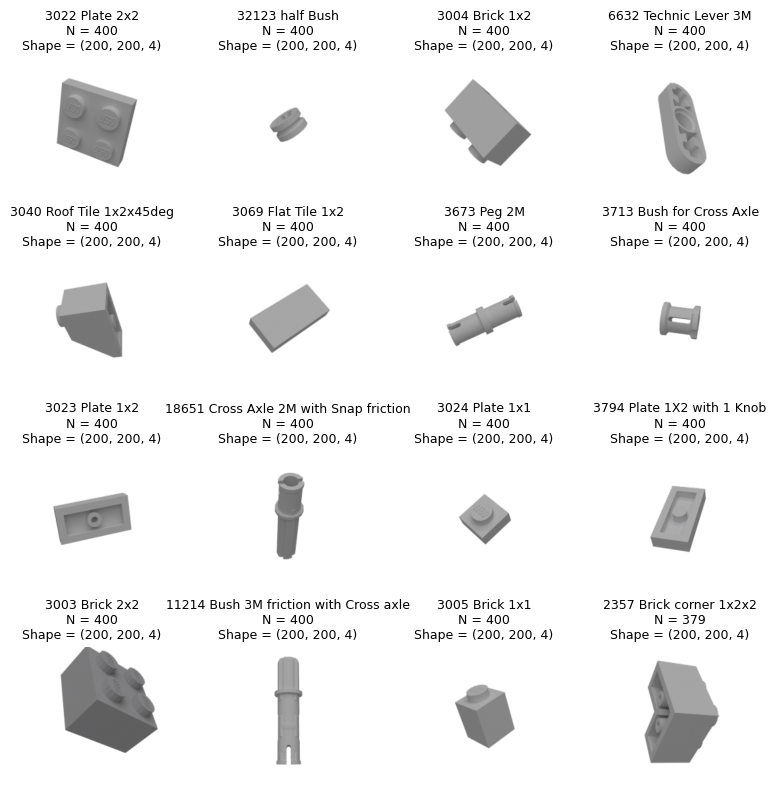

In [1]:
# @title
import os

import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import skimage

# Download latest version
clean_data_path = kagglehub.dataset_download("joosthazelzet/lego-brick-images")\
                    + "/LEGO brick images v1"

# Random seed
np.random.seed(2026)

# Read random files and display
f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):

    # Randomly select a block type and image
    block_group_dir = clean_data_path + "/" + os.listdir(clean_data_path)[i]
    block_file = block_group_dir + "/" + np.random.choice(os.listdir(block_group_dir))

    # Display
    arr = skimage.io.imread(block_file)
    ax[i].imshow(arr)
    ax[i].set_title(block_file.split("/")[-2] + "\n"\
                    + f"N = {len(os.listdir(block_group_dir))}" + "\n"\
                    + f"Shape = {arr.shape}", fontsize = 9.)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

 - As we saw in the lectures, medical images are less than when perfect compared with these examples.
 - They are affected by noise, blurring (_partial volume effects_), and artifacts.
 - We will create a function to artificially degrade these images, whilst also turning them into more _medical-like_ images (single channel with background being zero).  

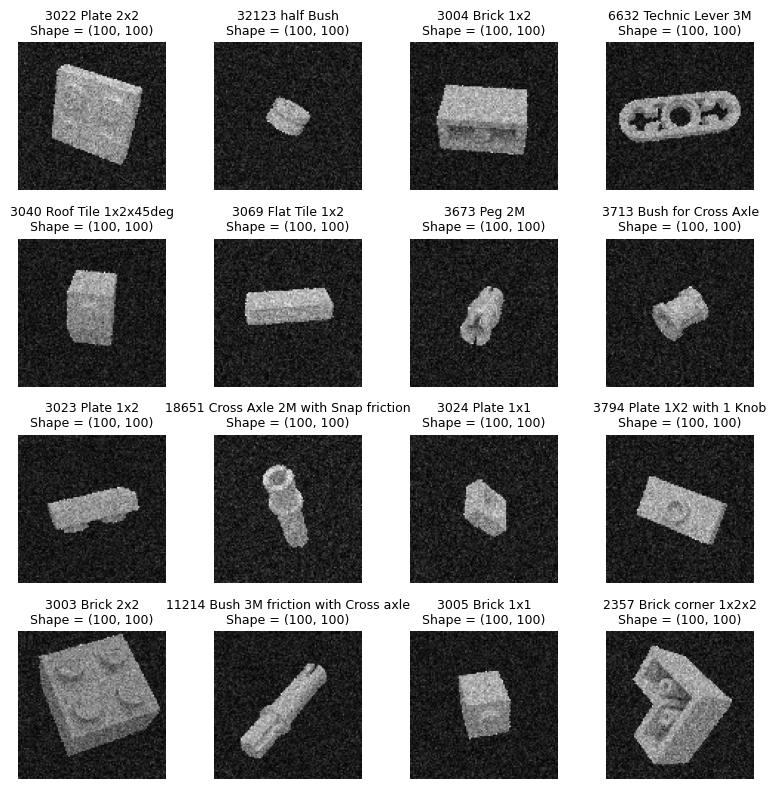

In [2]:
# @title
# Global parameters for the experiments
DOWNSAMPLE_FACTOR = 2
SNR = 12.0

def degrade_loego_image(arr, snr = 30.0, downsample = 4):
    """ Degrade the quality of an image of a Lego brick.

    Parameters
    ----------
    arr : numpy.ndarray
        The input image.

    snr : float, optional
        The signal-to-noise ratio.

    downsample : int, optional
        The downsampling factor.

    Returns
    -------
    numpy.ndarray
        The degraded image.
    """
    arr_bw = arr[::downsample, ::downsample, 0].astype("float32")
    sigma = 255.0 / snr

    # We use Rician noise to ensure non-negative values (as in medical imaging)
    arr_noisy = np.clip(np.sqrt((arr_bw + np.random.randn(*arr_bw.shape) * sigma) ** 2 +\
                                (np.random.randn(*arr_bw.shape) * sigma) ** 2), 0, 255)
    return arr_noisy.astype("uint8")


# Random seed
np.random.seed(2026)

f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):

    # Randomly select a block type and image
    block_group_dir = clean_data_path + "/" + os.listdir(clean_data_path)[i]
    block_file = block_group_dir + "/" + np.random.choice(os.listdir(block_group_dir))

    # Degrade the image.
    arr = skimage.io.imread(block_file)
    arr_noisy = degrade_loego_image(arr, snr=SNR, downsample=DOWNSAMPLE_FACTOR)

    # Display
    ax[i].imshow(arr_noisy, cmap = "gray")
    ax[i].set_title(block_file.split("/")[-2] + "\n"\
                    + f"Shape = {arr_noisy.shape}", fontsize = 9.)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

 - We will now store these degraded images seperately in a seperate file-system.
 - Files are stored in the location:
    
    `input_images_dir = "/content/input_images"`
    
 - This emulates the data you might have in real life.

In [3]:
from tqdm import tqdm

input_images_dir = "/content/input_images"

# Randomly select a block type and image
for block_group_dir in tqdm(os.listdir(clean_data_path), desc = "Resampling images"):
    block_group_path = clean_data_path + "/" + block_group_dir
    for block_file in os.listdir(block_group_path):
        block_path = block_group_path + "/" + block_file
        arr = skimage.io.imread(block_path)
        arr_noisy = degrade_loego_image(arr, snr=SNR, downsample=DOWNSAMPLE_FACTOR)
        os.makedirs(input_images_dir + "/" + block_group_dir, exist_ok=True)
        skimage.io.imsave(input_images_dir + "/" + block_group_dir + "/" + block_file, arr_noisy)

Resampling images: 100%|██████████| 16/16 [00:50<00:00,  3.17s/it]


## Binary Classifier
 - Our first exercise is to train a deep-learning neural network (DNN) to classify between two different block types.
 -

In [ ]:
from torch import nn

# Define the LeNet-based model
class LeNetBinary(nn.Module):
    def __init__(self):
        super(LeNetBinary, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 9 * 9, 120)  # Assuming input size 50x50
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 2)
        self.fc4 = nn.Linear(2, 1)

    def featurize(self, x):
        x = F.relu(self.conv1(x))  # conv1 -> ReLU activation
        x = F.max_pool2d(x, 2)     # Max pooling with 2x2 kernel
        x = F.relu(self.conv2(x))  # conv2 -> ReLU activation
        x = F.max_pool2d(x, 2)     # Max pooling with 2x2 kernel
        x = x.view(-1, 16 * 9 * 9) # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def classify(self, x):
        x = self.fc4(x)
        x = torch.sigmoid(x)  # Sigmoid activation for binary output
        return x

    def forward(self, x):
        x = self.featurize(x)
        x = self.classify(x)
        return x

['0051.png', '0327.png', '0195.png', '0025.png', '0249.png', '0220.png', '0129.png', '0126.png', '0041.png', '0298.png', '0207.png', '0314.png', '0104.png', '0096.png', '0163.png', '0066.png', '0106.png', '0393.png', '0174.png', '0291.png', '0217.png', '0113.png', '0324.png', '0078.png', '0374.png', '0293.png', '0050.png', '0226.png', '0357.png', '0333.png', '0261.png', '0064.png', '0364.png', '0315.png', '0252.png', '0047.png', '0133.png', '0061.png', '0099.png', '0349.png', '0070.png', '0059.png', '0386.png', '0183.png', '0087.png', '0354.png', '0022.png', '0246.png', '0101.png', '0387.png', '0128.png', '0281.png', '0114.png', '0348.png', '0343.png', '0300.png', '0399.png', '0056.png', '0171.png', '0073.png', '0309.png', '0260.png', '0299.png', '0049.png', '0198.png', '0149.png', '0384.png', '0307.png', '0297.png', '0074.png', '0316.png', '0212.png', '0222.png', '0058.png', '0373.png', '0369.png', '0038.png', '0016.png', '0169.png', '0138.png', '0010.png', '0156.png', '0032.png', '02

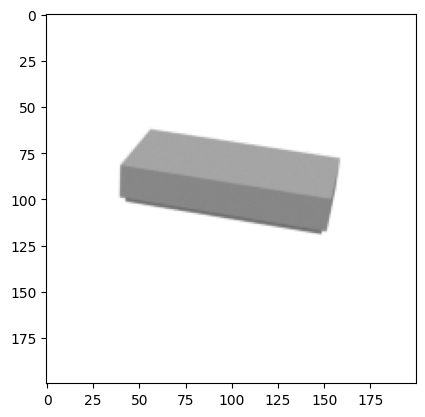

In [12]:
import os
import skimage
import matplotlib.pyplot as pl

print(os.listdir(path + "/LEGO brick images v1/3069 Flat Tile 1x2"))
im = skimage.io.imread(path + "/LEGO brick images v1/3069 Flat Tile 1x2/0051.png")
pl.imshow(im)